In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn_lvq.glvq import GlvqModel
from scipy.optimize import minimize

In [4]:
class PatchedGlvqModel(GlvqModel):
    def phi(self, x):
        x = np.asarray(x)
        return 1.0 / (1.0 + np.exp(-self.beta * x))

    def phi_prime(self, x):
        x = np.asarray(x)
        exp_term = np.exp(-self.beta * x)
        return self.beta * exp_term / (1.0 + exp_term) ** 2

    def _optimize(self, x, y, random_state):
        label_equals_prototype = y[np.newaxis].T == self.c_w_
        res = minimize(
            fun=lambda vs: self._optfun(
                variables=vs, training_data=x,
                label_equals_prototype=label_equals_prototype),
            jac=lambda vs: self._optgrad(
                variables=vs, training_data=x,
                label_equals_prototype=label_equals_prototype,
                random_state=random_state),
            method='l-bfgs-b',
            x0=self.w_.ravel(),
            options={'disp': self.display, 'gtol': self.gtol,
                     'maxiter': self.max_iter}
        )
        self.w_ = res.x.reshape(self.w_.shape)
        self.n_iter_ = getattr(res, "nit", getattr(res, "niter", None))

In [5]:
data = [
    ["Sunny","Hot","High","Weak","No"],
    ["Sunny","Hot","High","Strong","No"],
    ["Overcast","Hot","High","Weak","Yes"],
    ["Rain","Mild","High","Weak","Yes"],
    ["Rain","Cool","Normal","Weak","Yes"],
    ["Rain","Cool","Normal","Strong","No"]
]

In [6]:
df = pd.DataFrame(data, columns=["Outlook","Temperature","Humidity","Wind","PlayTennis"])

# Features + label
X = df[["Outlook","Temperature","Humidity","Wind"]]
y = df["PlayTennis"]

In [7]:
encoders = {}
X_enc = pd.DataFrame()
for col in X.columns:
    le = LabelEncoder()
    X_enc[col] = le.fit_transform(X[col])
    encoders[col] = le

In [8]:
# Encode label
le_label = LabelEncoder()
y_enc = le_label.fit_transform(y)  # 0/1 for No/Yes

# Normalize to [0,1]
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_enc)

In [9]:
strat = y_enc if len(np.unique(y_enc)) > 1 and len(y_enc) >= 2 else None
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_enc, test_size=0.2, random_state=42, stratify=strat
)

In [10]:
model = PatchedGlvqModel()
model.fit(X_train, y_train)

,prototypes_per_class,1
,initial_prototypes,None
,max_iter,2500
,gtol,1e-05
,beta,2
,c,None
,display,False
,random_state,None


In [11]:
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"PlayTennis test accuracy (Patched GLVQ): {acc*100:.2f}%")

PlayTennis test accuracy (Patched GLVQ): 50.00%


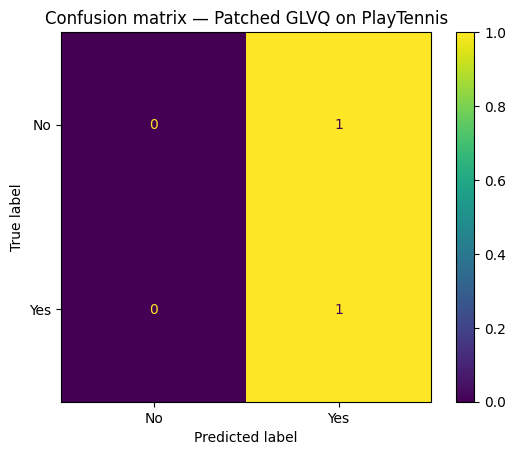

In [12]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le_label.classes_)
disp.plot(values_format='d')
plt.title("Confusion matrix — Patched GLVQ on PlayTennis")
plt.show()